In [49]:
import time

import matplotlib.pyplot as plt
from rtde_receive import RTDEReceiveInterface
from rtde_control import RTDEControlInterface

# --- 1. Connection Parameters ---
ROBOT_IP = "192.168.8.4"  # Replace with your UR5e's IP address

# Drop stale handles from earlier notebook runs so later cells do not
# silently reuse an old connection after a failed reconnect attempt.
for interface_name in ("rtde_c", "rtde_r"):
    if interface_name in globals():
        try:
            globals()[interface_name].disconnect()
        except Exception:
            pass
        globals()[interface_name] = None

print("Connecting to robot...")
rtde_r = None
rtde_c = None

try:
    rtde_r = RTDEReceiveInterface(ROBOT_IP)
    rtde_c = RTDEControlInterface(ROBOT_IP)
    print("Connected successfully.")
except RuntimeError as exc:
    raise RuntimeError(
        "Failed to claim RTDE control. Another client or fieldbus is using the robot's RTDE input registers. "
        "Disable EtherNet/IP, PROFINET, or MODBUS if enabled, close any other RTDE client, then rerun Cell 1."
    ) from exc

Connecting to robot...
Connected successfully.


In [50]:

# --- 2. Payload Configuration ---
# setPayload(mass in kg, [CoG_x, CoG_y, CoG_z] in meters)
# We set this to near-zero for now since you have no pen holder attached.
# When you attach your holder, update these values.
mass = 0.01
cog = [0.0, 0.0, 0.0]
rtde_c.setPayload(mass, cog)
print("Payload set.")


Payload set.


In [51]:

# --- 3. Sensor Taring ---
# This is crucial. It zeroes out the gravity effect on the sensor
# in the robot's current posture. Do not move the robot after calling this
# before starting your push test.
print("Taring F/T sensor... Do not touch the robot.")
rtde_c.zeroFtSensor()
time.sleep(1.0) # Give it a moment to stabilize
print("Sensor tared. Ready for pushing!")


Taring F/T sensor... Do not touch the robot.
Sensor tared. Ready for pushing!


Recording for 10.0 seconds. Push the flange upwards/downwards now!
Recording complete. Plotting data...


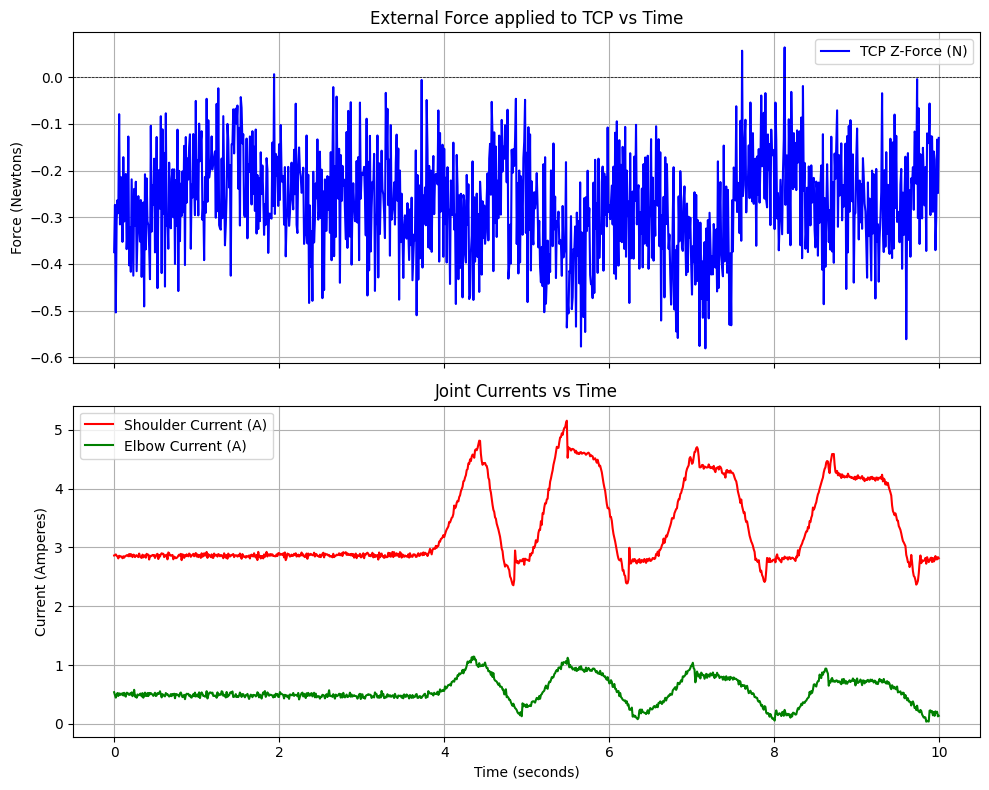

In [23]:

# --- 4. Data Collection ---
duration = 10.0  # seconds to record
start_time = time.time()

# Lists to store our data for plotting
timestamps = []
fz_data = []          # TCP Z-axis force
shoulder_current = [] # Joint 1
elbow_current = []    # Joint 2

print(f"Recording for {duration} seconds. Push the flange upwards/downwards now!")

while (time.time() - start_time) < duration:
    current_time = time.time() - start_time

    # Read TCP Force vector [Fx, Fy, Fz, Tx, Ty, Tz]
    tcp_forces = rtde_r.getActualTCPForce()

    # Read Joint Currents [Base, Shoulder, Elbow, Wrist1, Wrist2, Wrist3]
    joint_currents = rtde_r.getActualCurrent()

    # Store the data
    timestamps.append(current_time)
    fz_data.append(tcp_forces[2])           # Index 2 is Fz
    shoulder_current.append(joint_currents[1]) # Index 1 is Shoulder
    elbow_current.append(joint_currents[2])    # Index 2 is Elbow

    # Run loop at roughly 100Hz
    time.sleep(0.01)

print("Recording complete. Plotting data...")

# --- 5. Plotting the Results ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot TCP Z-Force
ax1.plot(timestamps, fz_data, color='blue', label='TCP Z-Force (N)')
ax1.set_ylabel('Force (Newtons)')
ax1.set_title('External Force applied to TCP vs Time')
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax1.legend()
ax1.grid(True)

# Plot Joint Currents
ax2.plot(timestamps, shoulder_current, color='red', label='Shoulder Current (A)')
ax2.plot(timestamps, elbow_current, color='green', label='Elbow Current (A)')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Current (Amperes)')
ax2.set_title('Joint Currents vs Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Keep the control session alive for later notebook cells.
# Run the cleanup cell at the bottom only when you are done with all robot commands.

In [52]:
import time

# --- Parameters ---
# Move straight down in TCP Z at 5 mm/s.
# (Negative Z is usually 'forward' out of the flange, depending on your TCP orientation)
SEARCH_SPEED = [0.0, 0.0, -0.005, 0.0, 0.0, 0.0]
ACCELERATION = 0.1      # Low acceleration for a smooth start
FORCE_THRESHOLD = 1.5   # Newtons. Well above your 0.2N noise floor!
CONTROL_PERIOD = 0.02   # 50 Hz pacing avoids overrunning the UR real-time thread from a notebook loop

if rtde_r is None or rtde_c is None:
    raise RuntimeError(
        "RTDE interfaces are not connected. Re-run Cell 1 after clearing any robot fault before running Cell 5."
    )

print(f"Starting surface search. Stopping when Z-force exceeds {FORCE_THRESHOLD} N.")

# Tare the sensor one last time right before moving to ensure a perfect 0.0 reading
rtde_c.zeroFtSensor()
time.sleep(0.5)

try:
    # Run the velocity command at a fixed controller period so the robot script
    # gets a paced stream of commands instead of an unbounded notebook loop.
    while True:
        cycle_start = rtde_c.initPeriod()
        command_ok = rtde_c.speedL(SEARCH_SPEED, ACCELERATION, CONTROL_PERIOD)
        rtde_c.waitPeriod(cycle_start)

        if not command_ok:
            raise RuntimeError("speedL command rejected because the RTDE control script is no longer running.")

        # Read the current force vector after the paced motion step.
        tcp_forces = rtde_r.getActualTCPForce()
        fz = tcp_forces[2]

        # The collision check
        if abs(fz) > FORCE_THRESHOLD:
            print(f"Contact detected! Force spiked to: {fz:.3f} N")

            # Stop the active speed command cleanly.
            rtde_c.speedStop(1.0)
            break

    # After breaking the loop and stopping, record the Cartesian pose
    contact_pose = rtde_r.getActualTCPPose()
    print("Surface confirmed. TCP coordinates recorded.")
    print(f"X: {contact_pose[0]:.4f}, Y: {contact_pose[1]:.4f}, Z: {contact_pose[2]:.4f}")

    # --- Optional: Auto-Retract ---
    # Back away 5mm immediately after finding the surface to release the pressure
    print("Retracting 5mm...")
    contact_pose[2] += 0.005 # Adjust sign if your TCP Z points the other way
    rtde_c.moveL(contact_pose, 0.05, 0.05)
    print("Search routine complete.")

except KeyboardInterrupt:
    # Catch manual stops from the notebook safely
    print("Search manually interrupted by user.")
    rtde_c.speedStop(1.0)
except RuntimeError as exc:
    try:
        rtde_c.speedStop(1.0)
    except Exception:
        pass
    raise RuntimeError(
        "The RTDE control script stopped on the robot. Clear the robot popup/fault, rerun Cells 1-3, then try Cell 5 again."
    ) from exc

Starting surface search. Stopping when Z-force exceeds 1.5 N.
Contact detected! Force spiked to: 1.700 N
Surface confirmed. TCP coordinates recorded.
X: 0.0571, Y: -0.4697, Z: -0.1293
Retracting 5mm...
Search routine complete.


In [54]:
import time
import numpy as np

# --- Parametreler ---
SEARCH_SPEED = [0.0, 0.0, -0.005, 0.0, 0.0, 0.0]
ACCELERATION = 0.1
FORCE_THRESHOLD = 1.5
CONTROL_PERIOD = 0.02
RETRACT_DIST = 0.010    # Yuzeyden 1 cm yukari cekilme
XY_OFFSET = 0.05        # 5 cm offset

# Orijinal (merkez) baslangic noktamiz
START_X = 0.0571
START_Y = -0.4697
SAFE_Z = -0.1000        # Yuzeyin kesinlikle uzerinde olan guvenli bir Z yuksekligi

if rtde_r is None or rtde_c is None:
    raise RuntimeError(
        "RTDE interfaces are not connected. Re-run Cells 1-3 before running Cell 6."
    )

# 5 nokta: merkez + 4 komsu nokta
grid_offsets = [
    (0.0, 0.0),
    (XY_OFFSET, 0.0),
    (-XY_OFFSET, 0.0),
    (0.0, XY_OFFSET),
    (0.0, -XY_OFFSET),
]

collected_points = []

def probe_surface():
    """Bulundugu XY konumunda asagi inip yuzeyi bulur ve TCP pozunu dondurur."""
    rtde_c.zeroFtSensor()
    time.sleep(0.5)

    while True:
        cycle_start = rtde_c.initPeriod()
        command_ok = rtde_c.speedL(SEARCH_SPEED, ACCELERATION, CONTROL_PERIOD)
        rtde_c.waitPeriod(cycle_start)

        if not command_ok:
            raise RuntimeError("RTDE control script stopped during surface probing.")

        tcp_forces = rtde_r.getActualTCPForce()
        fz = tcp_forces[2]

        if abs(fz) > FORCE_THRESHOLD:
            rtde_c.speedStop(1.0)
            return rtde_r.getActualTCPPose()

print("5 noktali tarama baslatiliyor...")

try:
    for i, (dx, dy) in enumerate(grid_offsets):
        target_x = START_X + dx
        target_y = START_Y + dy

        # 1. Guvenli yukseklige ve hedef XY'ye git
        print(f"Nokta {i+1}/5'e gidiliyor: X={target_x:.4f}, Y={target_y:.4f}")
        approach_pose = rtde_r.getActualTCPPose()
        approach_pose[0] = target_x
        approach_pose[1] = target_y
        approach_pose[2] = SAFE_Z
        rtde_c.moveL(approach_pose, 0.1, 0.1)

        # 2. Yuzeyi bul
        hit_pose = probe_surface()
        hit_point = [hit_pose[0], hit_pose[1], hit_pose[2]]
        collected_points.append(hit_point)
        print(f"  Temas! Z yuksekligi: {hit_pose[2]:.4f}")

        # 3. Yuzeyden guvenlice geri cekil
        hit_pose[2] += RETRACT_DIST
        rtde_c.moveL(hit_pose, 0.1, 0.1)

    if len(collected_points) < 3:
        raise RuntimeError("Duzlem uydurmak icin en az 3 temas noktasi gerekli.")

    print("\nTarama tamamlandi! En kucuk kareler ile duzlem hesaplaniyor...")

    # --- Least Squares ile Duzlem Cikarimi ---
    points = np.array(collected_points, dtype=float)
    x_vals = points[:, 0]
    y_vals = points[:, 1]
    z_vals = points[:, 2]

    # z = a*x + b*y + c seklinde duzlem uydur
    design_matrix = np.column_stack((x_vals, y_vals, np.ones(len(points))))
    coeffs, residuals, _, _ = np.linalg.lstsq(design_matrix, z_vals, rcond=None)
    a, b, c = coeffs

    # z = a*x + b*y + c denklemini A*x + B*y + C*z + d = 0 formuna cevir
    raw_normal = np.array([-a, -b, 1.0])
    normal_scale = np.linalg.norm(raw_normal)
    normal = raw_normal / normal_scale
    d = -c / normal_scale

    z_fit = design_matrix @ coeffs
    fit_errors = z_vals - z_fit
    rmse = float(np.sqrt(np.mean(fit_errors ** 2)))

    print("\n=== SONUCLAR ===")
    print("Elde edilen 5 nokta:")
    for idx, point in enumerate(points):
        print(f" P{idx+1}: {point}")

    print("\nLeast squares duzlem denklemi:")
    print(f"{normal[0]:.6f}*x + {normal[1]:.6f}*y + {normal[2]:.6f}*z + {d:.6f} = 0")
    print(f"Duzlem normal vektoru: {normal}")
    print(f"z = {a:.6f}*x + {b:.6f}*y + {c:.6f}")
    print(f"RMSE: {rmse:.6f} m")

except KeyboardInterrupt:
    print("Tarama kullanici tarafindan durduruldu.")
    try:
        rtde_c.speedStop(1.0)
    except Exception:
        pass
except RuntimeError as exc:
    try:
        rtde_c.speedStop(1.0)
    except Exception:
        pass
    raise RuntimeError(
        "Cell 6 durdu çünkü RTDE control script calismayi birakti. Robot fault/popup temizleyip Cells 1-3'u yeniden calistirin, sonra Cell 6'yi tekrar deneyin."
    ) from exc

5 noktali tarama baslatiliyor...
Nokta 1/5'e gidiliyor: X=0.0571, Y=-0.4697
  Temas! Z yuksekligi: -0.1293
Nokta 2/5'e gidiliyor: X=0.1071, Y=-0.4697
  Temas! Z yuksekligi: -0.1288
Nokta 3/5'e gidiliyor: X=0.0071, Y=-0.4697
  Temas! Z yuksekligi: -0.1296
Nokta 4/5'e gidiliyor: X=0.0571, Y=-0.4197
  Temas! Z yuksekligi: -0.1304
Nokta 5/5'e gidiliyor: X=0.0571, Y=-0.5197
  Temas! Z yuksekligi: -0.1281

Tarama tamamlandi! En kucuk kareler ile duzlem hesaplaniyor...

=== SONUCLAR ===
Elde edilen 5 nokta:
 P1: [ 0.05707354 -0.46966018 -0.12926029]
 P2: [ 0.1070891  -0.4696849  -0.12881151]
 P3: [ 0.00712116 -0.46971584 -0.12959773]
 P4: [ 0.05708795 -0.41969281 -0.13036079]
 P5: [ 0.05709736 -0.51972294 -0.1280971 ]

Least squares duzlem denklemi:
-0.007870*x + 0.022623*y + 0.999713*z + 0.140264 = 0
Duzlem normal vektoru: [-0.00786961  0.02262314  0.99971309]
z = 0.007872*x + -0.022630*y + -0.140304
RMSE: 0.000020 m


RTDEReceiveInterface boost system Exception: (asio.misc:2) End of file
RTDEControlInterface: Could not receive data from robot...
RTDEControlInterface Exception: End of file
RTDEControlInterface: Robot is disconnected, reconnecting...
RTDEControlInterface Exception: Timeout connecting to UR dashboard server.


Reconnecting...


In [48]:
# Optional cleanup: run this only when you are completely done commanding the robot.
if 'rtde_c' in globals() and rtde_c is not None:
    rtde_c.stopScript()
    try:
        rtde_c.disconnect()
    except Exception:
        pass

if 'rtde_r' in globals() and rtde_r is not None:
    try:
        rtde_r.disconnect()
    except Exception:
        pass

rtde_c = None
rtde_r = None
print("RTDE connections closed.")

RTDE connections closed.
